____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# wd_model = 'rio' or 'agesc'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

In [3]:
def compute_mean_square(ds):
    var = ['acc', 'cor', 'ggd', 'wd','sum']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']
    dss = (ds[[v+'n' for v in var] + [v+'e' for v in var]]**2).mean(dim='row_number').rename({var[i]+'n' : VAR[i]+'n' for i in range(5)}).rename({var[i]+'e' : VAR[i]+'e' for i in range(5)})
    dss['sigmae'] = dss.ACCe + dss.CORe + dss.GGDe + dss.WDe
    dss['sigman'] = dss.ACCn + dss.CORn + dss.GGDn + dss.WDn
    dss['nb_coloc'] = len(ds.row_number)
    #Balanced and error
    for direction in ['e', 'n']:
        for v in ['acc', 'cor', 'ggd', 'wd'] : 
                dss['B'+direction+'_'+v] = -((ds[v+direction]*ds['exc'+direction+'_'+v])).mean(dim='row_number')
                dss['E'+direction+'_'+v] = ((ds[v+direction]*ds['sum'+direction])).mean(dim='row_number')
    #pairs contributions
    for v in [v for v in ds if 'prod' in v]:
        dss[v.replace('prod', 'X')]=-2*ds[v].mean(dim='row_number')
    return dss

__________________
## ATTENTION : Select driftersource=LOWESS dans diagnosis.py

nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__agesc_0era5
8.177251838668088
8.655844793725493
8.391841937694052
8.673994445203473
9.20205008919355
9.826377561725517
9.348540882132168
9.769615684164656


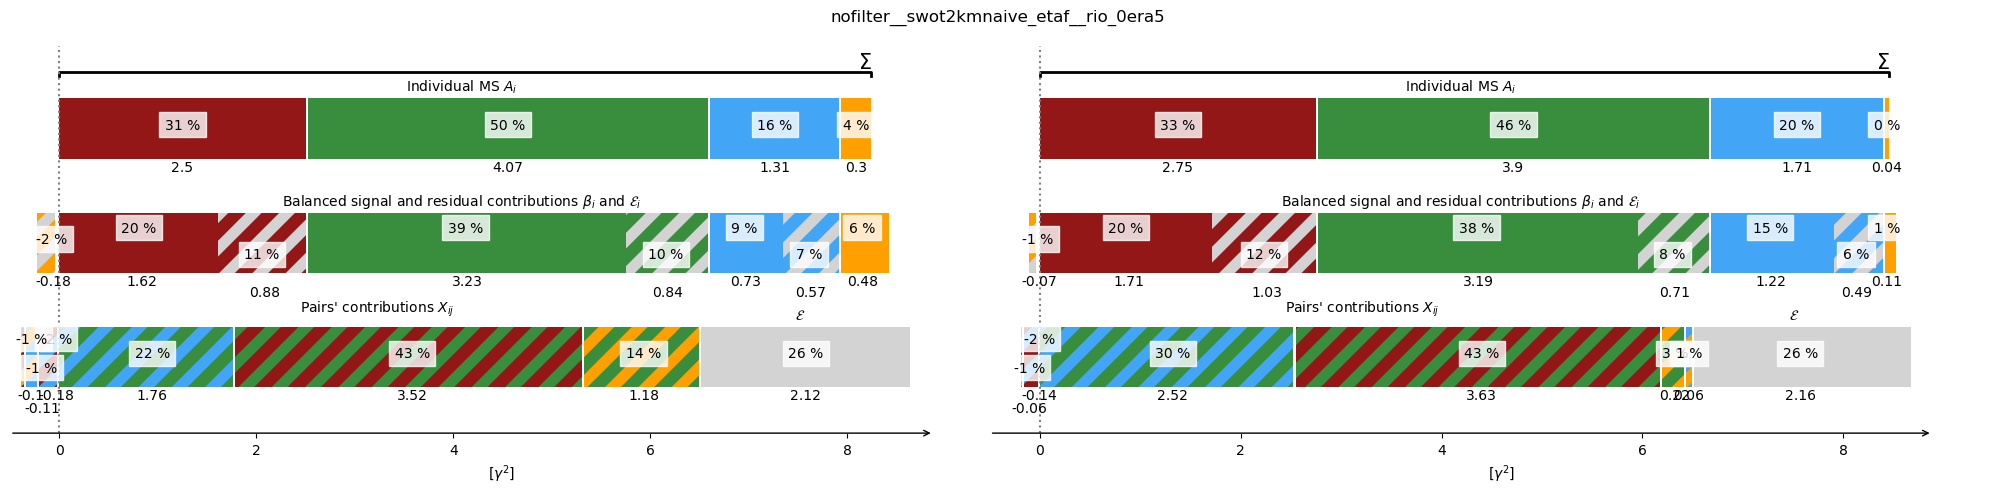

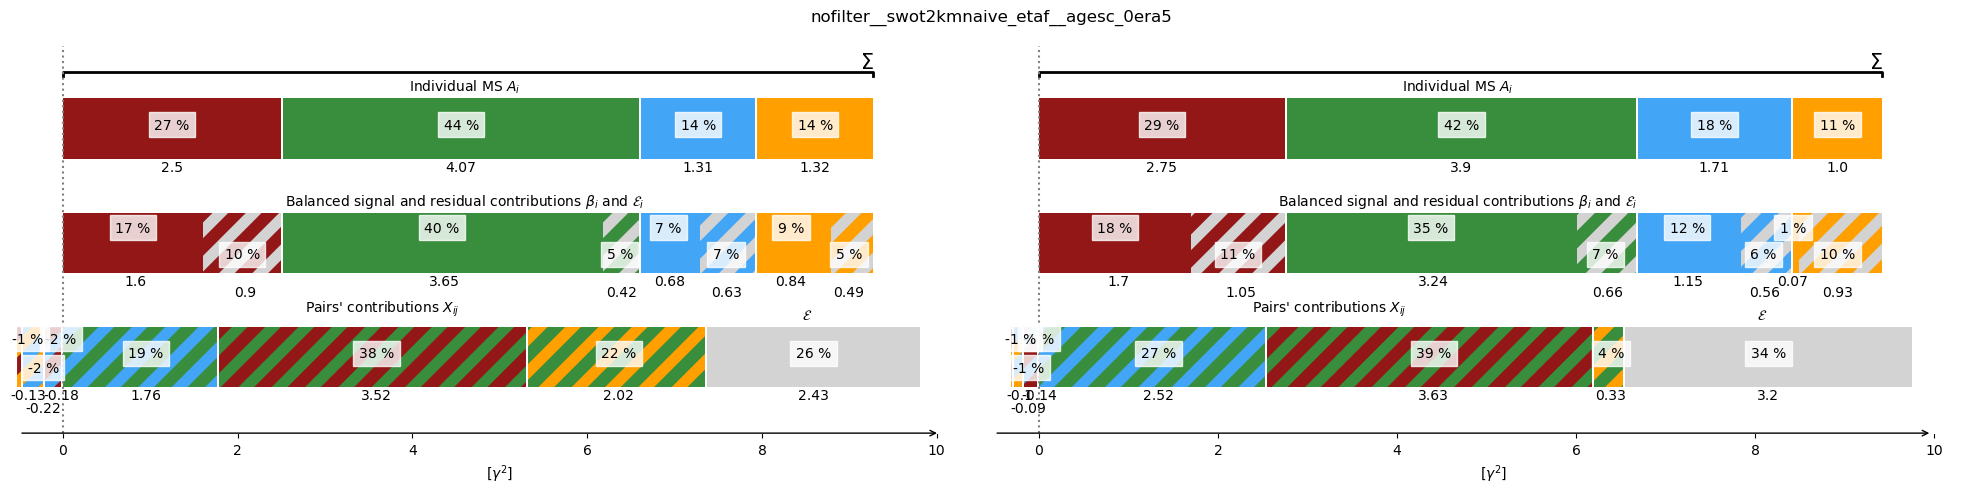

In [5]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0', wd_model='rio'), 
             dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0', wd_model='agesc')]

DS = dataset_coloc_combs(comb_list, nearest =False).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True)
DSD = DS.where(DS.depth==15, drop=True)
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e')
    synthetic_figure(df.loc[c], axs[1], dir='n')
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir,'lowess', 'closure_figs', c + '.png'))